## Setup Libraries

In [1]:
# !pip install -q uv

In [2]:
import torch
import os, sys
import numpy as np, random
from scipy.stats import norm
import pandas as pd

from colorama import Fore, Style
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from importlib.metadata import version

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 100)

In [3]:
# !pip install git+https://github.com/bartz-org/bartz.git
!uv pip install bartz

# if torch.cuda.is_available():
#     !pip install -qq bartz[cuda13]

Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 258ms
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
bartz                ------------------------------     0 B/217.87 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14.84 KiB/20.04 KiB
bartz                ------------------------------     0 B/217.87 KiB
⠙ Preparing packages... (0/5)
wadler-lindig        ------------------------------ 14

In [4]:
from bartz.BART import gbart, mc_gbart
# from bartz import Bart

!pip show bartz

Name: bartz
Version: 0.12.1
Summary: Super-fast BART (Bayesian Additive Regression Trees) in Python
Home-page: https://github.com/bartz-org/bartz
Author: 
Author-email: Giacomo Petrillo <info@giacomopetrillo.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: equinox, jax, jaxtyping, numpy, scipy, tqdm, typing-extensions
Required-by: 


## Load Data

In [5]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


## Preprocess Features

In [6]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')#⚠️

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')#⚠️
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')#⚠️
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')#⚠️
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')#⚠️

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')#⚠️

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Income_USD_is_multiple_10_'] = (
        np.floor(df['Annual_Income_USD']) % 10 == 0
    ).astype('int32').astype('category')#⚠️

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 3.98 s, sys: 597 ms, total: 4.58 s
Wall time: 4.59 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,0,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,1,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,0,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,1,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,0,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,1,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,1,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,0,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,0,0.175000,2,307,459,612,689,838,14312,16,9197


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 35 columns):
 #   Column                                  Non-Null Count   Dtype   
---  ------                                  --------------   -----   
 0   Age                                     668665 non-null  int64   
 1   Annual_Income_USD                       668665 non-null  float64 
 2   Daily_Commute_km                        668665 non-null  float64 
 3   Number_of_Cars_Owned                    668665 non-null  int64   
 4   Charging_Stations_Near_Home             668665 non-null  int64   
 5   Charging_Stations_Near_Work             668665 non-null  int64   
 6   Environmental_Concern_Level             668665 non-null  float64 
 7   Gender                                  668665 non-null  category
 8   City_Type                               668665 non-null  category
 9   Current_Car_Type                        668665 non-null  category
 10  Home_Charging_Possible          

## Config

In [8]:
## -- Tell JAX to use all and only 95% of the GPU memory
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = '.95'

print("📥 Memory limited to 95% usage")

📥 Memory limited to 95% usage


In [9]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(
    pd.concat([X, y], axis=1),
    train_size=300_000,
    stratify=y,
    random_state=0,
)

train_X = pd.concat([X, y], axis=1) if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,0,0.000000,96,214,321,427,482,584,0,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,1,0.066427,61605,0,0,0,0,0,1,1,1,0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,0,1.000000,45,225,336,448,505,612,2,2,2,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,1,1.000000,177,96,144,191,216,262,3,0,3,0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,0,0.500000,290,27,40,53,60,73,4,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,1,1.000000,81,80,119,159,180,218,9486,47,6094,0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,1,0.000000,82,338,506,675,760,925,161,19,160,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,0,0.000000,175,321,480,640,721,876,3076,45,2836,0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,0,0.175000,2,307,459,612,689,838,14312,16,9197,0


## Train K-Fold

In [10]:
%%time

ENGINE = 'pbart'
MODEL_NAME = f"BARTZ{ENGINE[0]}_mlp"

PREDICT_TEST = False
USE_TE = True
FOLDS  = 10

print(f"\n 🚀 Training {MODEL_NAME} with {FOLDS } folds...")

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET]

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X_1))
test_preds = np.zeros(len(X_test))

fold_scores = []
feat_importances = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    X_tr, X_val = X_1.iloc[tr_idx], X_1.iloc[val_idx]
    y_tr, y_val = y_1.iloc[tr_idx], y_1.iloc[val_idx]
    X_tst = X_test.copy()  

    # --- Target encoding ---
    if USE_TE:
        te_cols = combo_names
        print(f"Target encoding ({len(te_cols)}) features")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        val_enc = TE.transform(X_val[te_cols])
        tst_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = val_enc
        X_tst[te_names] = tst_enc

        X_tr.drop(columns=te_cols, inplace=True)
        X_val.drop(columns=te_cols, inplace=True)
        X_tst.drop(columns=te_cols, inplace=True)

    # --- Accelerated training ---
    params = {
        "type": ENGINE,
        # # 'ntree':  100, # d=50
        # # 'ndpost': 2000, # d=1000
        # # 'nskip':  150, # d=100
        # # 'k': 4.0, # d=2.0
        # # 'numcut': 255, # d=100
        # # 'usequants': True,
        # 'sparse': True,
        # 'augment':True,
        'mc_cores': 4, # d=2
        'keepevery': 50, # d=10
        "seed": 42,
    }

    # if fold == 1: print("len(FEATURES):", len(X_tr.columns.tolist()), "\n")
    print(f"### Fold {fold}/{FOLDS} | ⚡️{ENGINE}", end=" | ")
    print(f"train={X_tr.shape}, val={X_val.shape}")
    print("-"*60)

    model = mc_gbart(
        X_tr.to_numpy(),
        y_tr.astype(bool).to_numpy() if ENGINE=="pbart" else y_tr.astype('float32').to_numpy(),
        x_test=X_tst.to_numpy(),
        **params,
    )

    oof_preds[val_idx] = norm.cdf(model.predict(X_val.to_numpy()).mean(axis=0).ravel())
    test_preds += model.prob_test_mean / FOLDS

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(fold_auc)

    print(f"{"-"*60}")
    
    # if ENGINE=="pbart":
    #     print(f" -> Post {fold} AUC: {roc_auc_score(y_val, model.prob_test_mean):.6f}")

    if PREDICT_TEST:
        print('test predictions ⧗')
        test_preds += norm.cdf(model.predict(X_tst.to_numpy()).mean(axis=0).ravel()) / FOLDS

    print(f"{Fore.YELLOW}{Style.BRIGHT}-> Fold {fold} AUC: {fold_auc:.6f}{Style.RESET_ALL}\n")

    # del model, X_tr, y_tr, y_val, X_tst
    torch.cuda.empty_cache()

oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

## -- CV summary --
print('\n'+'='*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | shape: {X_tr.shape}")
print('='*50)
for i, score in enumerate(fold_scores, 1): 
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


 🚀 Training BARTZp_mlp with 10 folds...
Target encoding (3) features
### Fold 1/10 | ⚡️pbart | train=(601798, 35), val=(66867, 35)
------------------------------------------------------------


  0%|          | 0/12600 [00:00<?, ?it/s]

------------------------------------------------------------
-> Fold 1 AUC: 0.944659

Target encoding (3) features
### Fold 2/10 | ⚡️pbart | train=(601798, 35), val=(66867, 35)
------------------------------------------------------------


  0%|          | 0/12600 [00:00<?, ?it/s]

------------------------------------------------------------
-> Fold 2 AUC: 0.944683

Target encoding (3) features
### Fold 3/10 | ⚡️pbart | train=(601798, 35), val=(66867, 35)
------------------------------------------------------------


...

------------------------------------------------------------
-> Fold 8 AUC: 0.946399

Target encoding (3) features
### Fold 9/10 | ⚡️pbart | train=(601799, 35), val=(66866, 35)
------------------------------------------------------------


  0%|          | 0/12600 [00:00<?, ?it/s]

------------------------------------------------------------
-> Fold 9 AUC: 0.946573

Target encoding (3) features
### Fold 10/10 | ⚡️pbart | train=(601799, 35), val=(66866, 35)
------------------------------------------------------------


  0%|          | 0/12600 [00:00<?, ?it/s]

------------------------------------------------------------
-> Fold 10 AUC: 0.944833


10-FOLD CV: BARTZp_mlp | shape: (601799, 35)
 • Fold 1 AUC: 0.944659
 • Fold 2 AUC: 0.944683
 • Fold 3 AUC: 0.945037
 • Fold 4 AUC: 0.945552
 • Fold 5 AUC: 0.946510
 • Fold 6 AUC: 0.946651
 • Fold 7 AUC: 0.945549
 • Fold 8 AUC: 0.946399
 • Fold 9 AUC: 0.946573
 • Fold 10 AUC: 0.944833
--------------------------------------------------
OOF AUC: 0.945643
AVG AUC: 0.945645 ± 0.000783
--------------------------------------------------
CPU times: user 1h 5min 4s, sys: 57.6 s, total: 1h 6min 1s
Wall time: 1h 6min 9s


In [11]:
# ==================================================
# 3-FOLD CV: BARTZp_mlp | shape: (200000, 38)
# ==================================================
#  • Fold 1 AUC: 0.944419
#  • Fold 2 AUC: 0.943907
#  • Fold 3 AUC: 0.942858
# --------------------------------------------------
# OOF AUC: 0.94371
# AVG AUC: 0.943728 ± 0.000650
# --------------------------------------------------
# CPU times: user 7min 40s, sys: 18.7 s, total: 7min 59s
# Wall time: 8min 1s

## --- CV summary --- 
print('='*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | shape: {X_tr.shape}")
print('='*50)
for i, score in enumerate(fold_scores, 1):
    print(f" • Fold {i} AUC: {score:.6f}")

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)

10-FOLD CV: BARTZp_mlp | shape: (601799, 35)
 • Fold 1 AUC: 0.944659
 • Fold 2 AUC: 0.944683
 • Fold 3 AUC: 0.945037
 • Fold 4 AUC: 0.945552
 • Fold 5 AUC: 0.946510
 • Fold 6 AUC: 0.946651
 • Fold 7 AUC: 0.945549
 • Fold 8 AUC: 0.946399
 • Fold 9 AUC: 0.946573
 • Fold 10 AUC: 0.944833
--------------------------------------------------
OOF AUC: 0.945643
AVG AUC: 0.945645 ± 0.000783
--------------------------------------------------


## Evaluation and Submission

In [12]:
_NAME = f"{MODEL_NAME}({X_val.shape[1]})_{oof_auc}"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{_NAME}.npy", oof_preds)
print(f"💾 Saved 'oof_{_NAME}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{_NAME}.npy", test_preds)
print(f"💾 Saved 'test_{_NAME}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{_NAME}.csv", index=False)
print(f"💾 Saved 'submission_{_NAME}.csv'")

print()
submission

💾 Saved 'oof_BARTZp_mlp(35)_0.945643.npy'
💾 Saved 'test_BARTZp_mlp(35)_0.945643.npy'
💾 Saved 'submission_BARTZp_mlp(35)_0.945643.csv'



,id,Will_Buy_EV
0,668665,0.047818
1,668666,0.023243
2,668667,0.003170
3,668668,0.002204
4,668669,0.031114
...,...,...
286566,955231,0.000044
286567,955232,0.280425
286568,955233,0.000218
286569,955234,0.000158


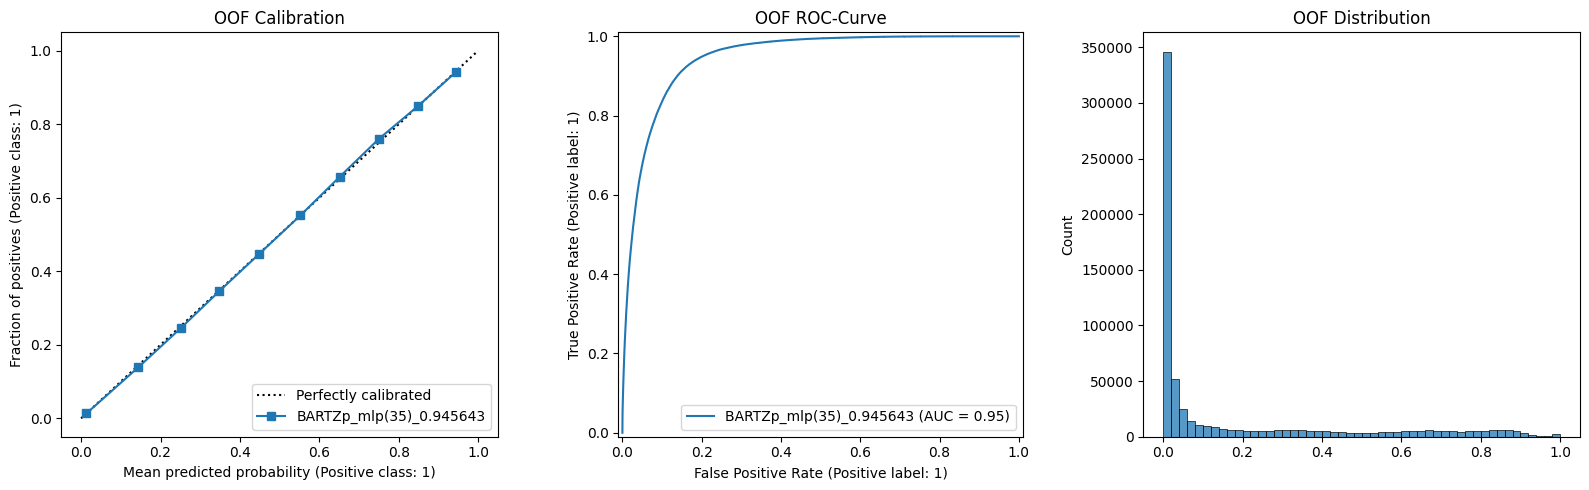

In [13]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [14]:
# !rm -r /kaggle/working/